# Question-level instances (no participant averaging)

The same encoders as notebook 01, but each answered question is its own
training instance instead of being averaged into one vector per participant:
110 participants become ~376 rows, each carrying its participant's score.

The motivation is the intrinsic diagnostic from Phase C: averaging a
participant's per-question embeddings pulls every vector toward the domain
centroid, leaving the regressor little to separate people by.

Two constraints keep the comparison valid: cross-validation is **grouped by
participant** (otherwise one answer in training and another in validation
would leak the label), and **evaluation stays at participant level** —
predictions are averaged within each participant before any metric — so
these arms are scored on the same held-out people as notebook 01.

Three sentence-transformer checkpoints run as separate arms in one pass
(small/base/large, 384/768/1024 dims, all with a 512-token context), so
encoder capacity and input granularity form a declared grid rather than a
sequence of one-off swaps (PROTOCOL.md, Section 7).

**All reported metrics are on the held-out test participants**, who are
never trained on and are the same set in every arm. Cross-validation numbers
appear only where labelled, and reflect model selection on training data.

In [15]:
%load_ext autoreload
%autoreload 2

import sys  
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from src import config, data, encoders, splits, logging_utils
from src.plotting import plot_confusion_matrix, BAND_LABELS, SCREENING_LABELS
from src.pipeline import TARGETS, arm_models, build_train_frame, \
    compute_frozen_question_embeddings, e5_arm, encoder_data, encoders_for, \
    expand_to_questions, question_documents, question_encoders_for, \
    run_encoder, search_label

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Run configuration

In [16]:
E5_MODELS = [
    "intfloat/multilingual-e5-small",   # 384 dims
    "intfloat/multilingual-e5-base",    # 768 dims
    "intfloat/multilingual-e5-large",   # 1024 dims
]

In [17]:
cfg = config.TrainingConfig(
    augmentation=config.AUGMENTATION_NONE,   # or config.AUGMENTATION_NONE  config.AUGMENTATION_LLM
    seeds=(42,),
    n_cv_splits=5,
    n_search_iter=0,      # 0 = sin busqueda; ver tune_model para afinar una familia
    beto_model="dccuchile/bert-base-spanish-wwm-cased",
    max_tokens=512,
    chunk_stride=256,
    tfidf_max_features=300,
    tfidf_ngram_range=(1, 2),
    tfidf_min_df=3,
    tfidf_max_df=0.90,
    tfidf_lemmatize=True,
    tfidf_normalize_numbers=True,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")
GRANULARITY = config.GRANULARITY_QUESTION
ARMS = question_encoders_for(cfg, E5_MODELS)
ALL_ARMS = encoders_for(cfg, E5_MODELS) + ARMS
ARM_MODELS = arm_models(cfg, E5_MODELS, question_level=True)
print("arms:", ARMS)
cfg

device: cuda
arms: ['E0_TFIDF_QUESTION', 'E1_BETO_QUESTION', 'E2_E5SMALL_QUESTION', 'E2_E5BASE_QUESTION', 'E2_E5LARGE_QUESTION', 'E7_ROBERTA_MENTAL_QUESTION']


TrainingConfig(augmentation='no_augmentation', seeds=(42,), n_cv_splits=5, n_search_iter=0, beto_model='dccuchile/bert-base-spanish-wwm-cased', sentence_transformer_model='intfloat/multilingual-e5-small', mental_es_model='ELiRF/RoBERTa-es-mental-large', max_tokens=512, chunk_stride=256, tfidf_max_features=300, tfidf_ngram_range=(1, 2), tfidf_min_df=3, tfidf_max_df=0.9, tfidf_lemmatize=True, tfidf_normalize_numbers=True)

In [18]:
df = data.load_dataset()
train_ids, test_ids = splits.train_test_participants(df)
train_frame, aug_groups = build_train_frame(df, train_ids, test_ids, cfg)
test_frame = df.loc[test_ids]

# With augmentation the group is the original participant, so a paraphrase
# never lands in a different fold than the answer it came from.
group_col = "original_participant" if aug_groups is not None else None
q_train = expand_to_questions(train_frame, group_col=group_col)
q_test = expand_to_questions(test_frame)

groups = q_train["group"].to_numpy()
test_groups = q_test["participant"].to_numpy()
N_TEST = len(test_frame)

print(f"train: {len(train_frame)} participants -> {len(q_train)} question rows")
print(f"test:  {N_TEST} participants -> {len(q_test)} question rows (evaluated per participant)")
display(q_train["question"].value_counts().sort_index().rename("training rows per question"))

train: 110 participants -> 376 question rows
test:  48 participants -> 168 question rows (evaluated per participant)


question
Q01    110
Q02    110
Q03    110
Q04     46
Name: training rows per question, dtype: int64

In [19]:
run_dir = config.results_dir(cfg.augmentation, granularity=GRANULARITY)
combined = pd.concat([q_train[["text"]], q_test[["text"]]])

embeddings = compute_frozen_question_embeddings(combined, device, cfg, run_dir, e5_models=E5_MODELS)
docs_all = question_documents(combined, cfg)
for name, matrix in embeddings.items():
    print(f"{name}: {matrix.shape}")

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 8595.02it/s]
[transformers] RobertaModel LOAD REPORT from: ELiRF/RoBERTa-es-mental-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (560 > 512). Running this sequence through the model will result in indexing errors


E1_BETO_QUESTION: (544, 768)
E2_E5SMALL_QUESTION: (544, 384)
E2_E5BASE_QUESTION: (544, 768)
E2_E5LARGE_QUESTION: (544, 1024)
E7_ROBERTA_MENTAL_QUESTION: (544, 1024)


In [20]:
def report_encoder(encoder_name, run_rows):
    runs = pd.DataFrame(run_rows)
    print(f"[TEST] {encoder_name}: metrics on the {N_TEST} held-out participants, per seed")
    display(runs.pivot(index="seed", columns="target", values=["rmse", "mae", "r2"]).round(3))

    # Filtered to this run's search regime: a defaults run and an earlier
    # tuned run of the same arm both live in the log, and pivoting over both
    # would collide on (model_name, seed).
    trials = logging_utils.load_trials(cfg.augmentation, granularity=GRANULARITY)
    trials = trials[(trials["encoder"] == encoder_name)
                    & (trials["search"] == search_label(cfg))]
    for target in TARGETS:
        print(f"[CROSS-VALIDATION on training data] RMSE per candidate regressor ({target}). "
              f"This is what model selection used; it is not a test score.")
        display(trials[trials["target"] == target].pivot(
            index="model_name", columns="seed", values="cv_rmse").round(3))

    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    for i, target in enumerate(TARGETS):
        target_runs = runs[runs["target"] == target]
        best_row = target_runs.loc[target_runs["rmse"].idxmin()]
        seed = int(best_row["seed"])
        plot_confusion_matrix(axes[i, 0], best_row["band_confusion_matrix"], BAND_LABELS,
                                f"{target} severity bands (seed={seed})")
        plot_confusion_matrix(axes[i, 1], best_row["screening_confusion_matrix"], SCREENING_LABELS,
                                f"{target} screening (seed={seed})")
    plt.suptitle(f"[TEST] {encoder_name}: confusion matrices, best seed per target")
    plt.tight_layout()
    plt.show()


def train_and_report(encoder_name):
    X_all, preprocessor = encoder_data(encoder_name, combined, docs_all, embeddings, cfg)
    X_train_enc = X_all.loc[q_train.index]
    X_test_enc = X_all.loc[q_test.index]
    t0 = time.time()
    run_rows = run_encoder(encoder_name, X_train_enc, X_test_enc, preprocessor,
                            q_train, q_test, groups, cfg,
                            test_groups=test_groups, notebook="02",
                            encoder_model=ARM_MODELS[encoder_name])
    print(f"{encoder_name} done in {(time.time()-t0)/60:.1f} min")
    report_encoder(encoder_name, run_rows)

### Stage 1: TF-IDF

E0_TFIDF_QUESTION seed=42 target=PHQ9 best=RandomForest rmse=5.292 r2=0.073 (14.9s)
E0_TFIDF_QUESTION seed=42 target=GAD7 best=RandomForest rmse=4.828 r2=0.079 (14.8s)
E0_TFIDF_QUESTION done in 0.5 min
[TEST] E0_TFIDF_QUESTION: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.828  5.292  3.978  4.301  0.079  0.073

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.888
DecisionTree,6.793
ExtraTrees,5.874
GradientBoosting,6.113
KNN,6.193
LightGBM,6.084
RandomForest,5.790
Ridge,6.053
SVR,5.906


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.094
DecisionTree,5.546
ExtraTrees,4.905
GradientBoosting,5.203
KNN,5.100
LightGBM,5.051
RandomForest,4.839
Ridge,5.229
SVR,5.009


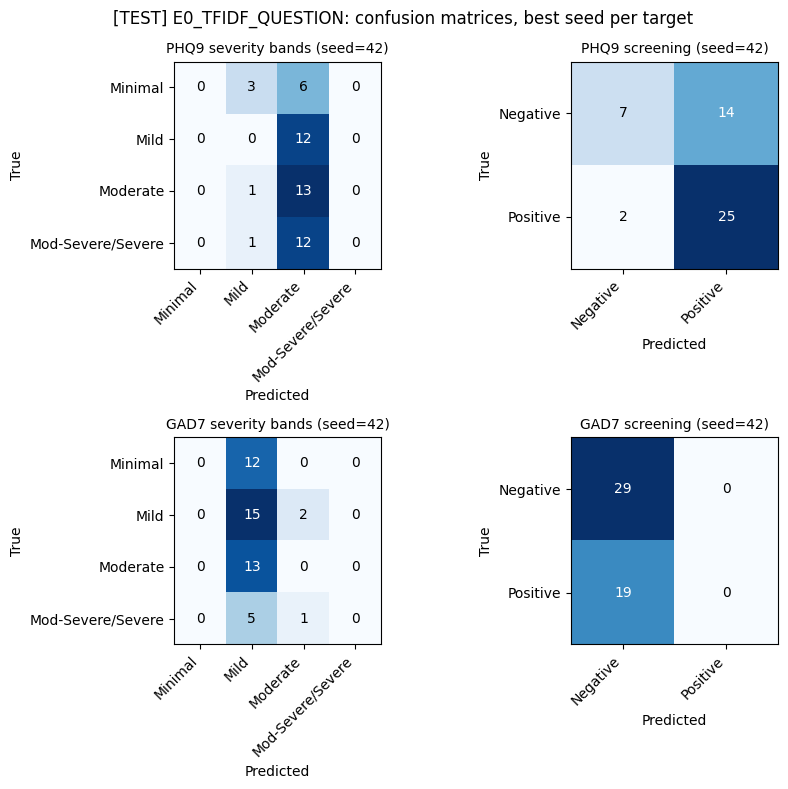

In [21]:
train_and_report("E0_TFIDF_QUESTION")

### Stage 2: BETO (frozen)

E1_BETO_QUESTION seed=42 target=PHQ9 best=SVR rmse=5.005 r2=0.170 (134.3s)
E1_BETO_QUESTION seed=42 target=GAD7 best=SVR rmse=4.559 r2=0.179 (133.8s)
E1_BETO_QUESTION done in 4.5 min
[TEST] E1_BETO_QUESTION: metrics on the 48 held-out participants, per seed


rmse          mae            r2      
target   GAD7   PHQ9  GAD7   PHQ9   GAD7  PHQ9
seed                                          
42      4.559  5.005  3.72  4.111  0.179  0.17

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.636
DecisionTree,7.562
ExtraTrees,5.654
GradientBoosting,5.758
KNN,6.068
LightGBM,5.860
RandomForest,5.635
Ridge,6.753
SVR,5.402


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.915
DecisionTree,6.216
ExtraTrees,4.741
GradientBoosting,4.980
KNN,5.117
LightGBM,4.990
RandomForest,4.754
Ridge,6.653
SVR,4.602


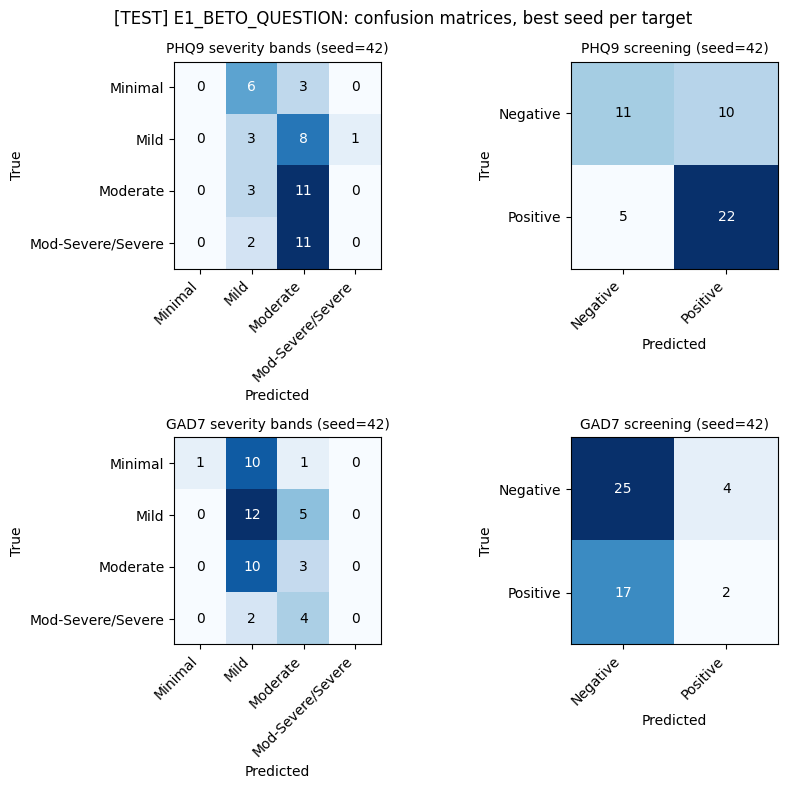

In [22]:
train_and_report("E1_BETO_QUESTION")

### Stage 3: e5-small (frozen)

E2_E5SMALL_QUESTION seed=42 target=PHQ9 best=SVR rmse=4.916 r2=0.200 (70.1s)
E2_E5SMALL_QUESTION seed=42 target=GAD7 best=SVR rmse=4.490 r2=0.204 (69.1s)
E2_E5SMALL_QUESTION done in 2.3 min
[TEST] E2_E5SMALL_QUESTION: metrics on the 48 held-out participants, per seed


rmse           mae            r2     
target  GAD7   PHQ9   GAD7   PHQ9   GAD7 PHQ9
seed                                         
42      4.49  4.916  3.675  4.044  0.204  0.2

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.786
DecisionTree,7.425
ExtraTrees,5.761
GradientBoosting,5.802
KNN,5.982
LightGBM,5.779
RandomForest,5.745
Ridge,10.934
SVR,5.530


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.904
DecisionTree,6.095
ExtraTrees,4.788
GradientBoosting,4.912
KNN,5.137
LightGBM,4.932
RandomForest,4.792
Ridge,9.250
SVR,4.706


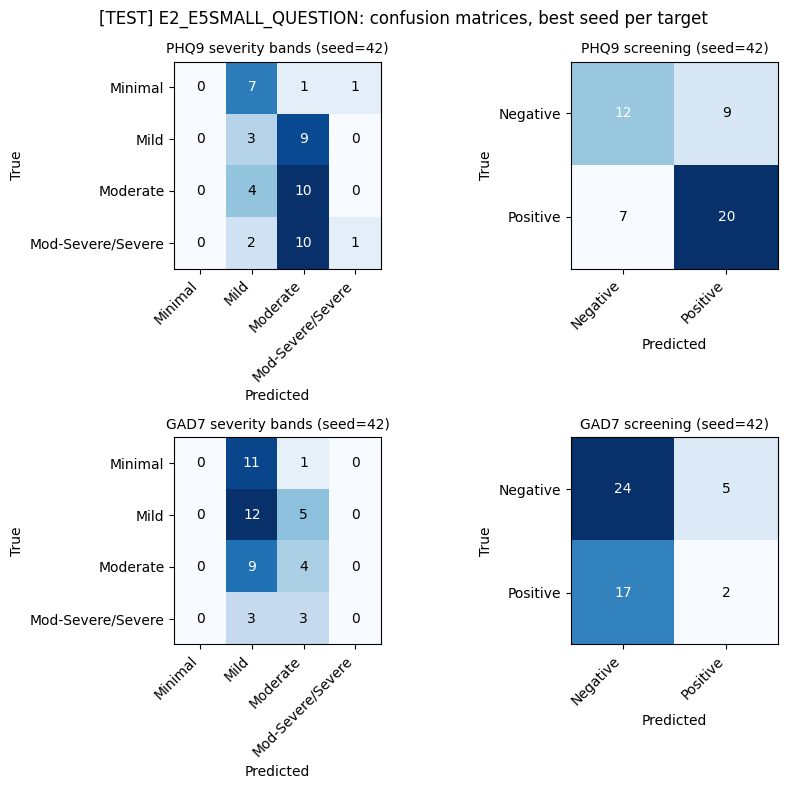

In [23]:
train_and_report(e5_arm(E5_MODELS[0], question_level=True))

### Stage 4: e5-base (frozen)

E2_E5BASE_QUESTION seed=42 target=PHQ9 best=SVR rmse=4.788 r2=0.241 (135.5s)
E2_E5BASE_QUESTION seed=42 target=GAD7 best=SVR rmse=4.376 r2=0.243 (135.2s)
E2_E5BASE_QUESTION done in 4.5 min
[TEST] E2_E5BASE_QUESTION: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.376  4.788  3.522  3.956  0.243  0.241

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.345
DecisionTree,7.492
ExtraTrees,5.499
GradientBoosting,5.452
KNN,5.566
LightGBM,5.424
RandomForest,5.440
Ridge,8.117
SVR,5.263


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.619
DecisionTree,5.916
ExtraTrees,4.651
GradientBoosting,4.677
KNN,4.941
LightGBM,4.773
RandomForest,4.629
Ridge,7.096
SVR,4.602


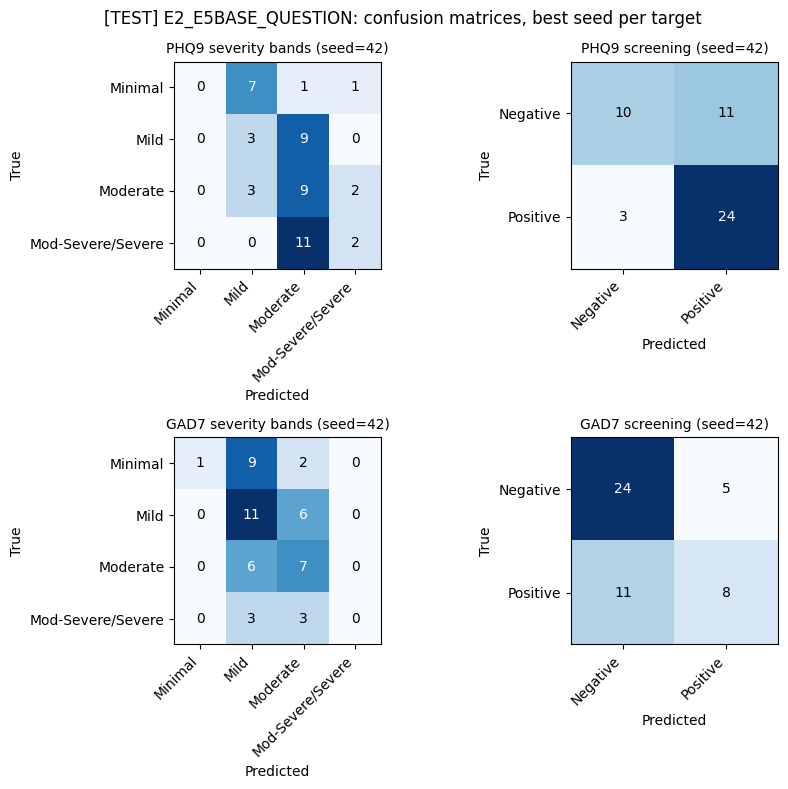

In [24]:
train_and_report(e5_arm(E5_MODELS[1], question_level=True))

### Stage 5: e5-large (frozen)

E2_E5LARGE_QUESTION seed=42 target=PHQ9 best=SVR rmse=4.634 r2=0.289 (178.4s)
E2_E5LARGE_QUESTION seed=42 target=GAD7 best=ExtraTrees rmse=4.541 r2=0.186 (179.2s)
E2_E5LARGE_QUESTION done in 6.0 min
[TEST] E2_E5LARGE_QUESTION: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.541  4.634  3.686  3.826  0.186  0.289

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.487
DecisionTree,6.779
ExtraTrees,5.436
GradientBoosting,5.569
KNN,5.383
LightGBM,5.609
RandomForest,5.451
Ridge,7.857
SVR,5.325


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.691
DecisionTree,5.978
ExtraTrees,4.582
GradientBoosting,4.707
KNN,4.854
LightGBM,4.876
RandomForest,4.591
Ridge,6.982
SVR,4.589


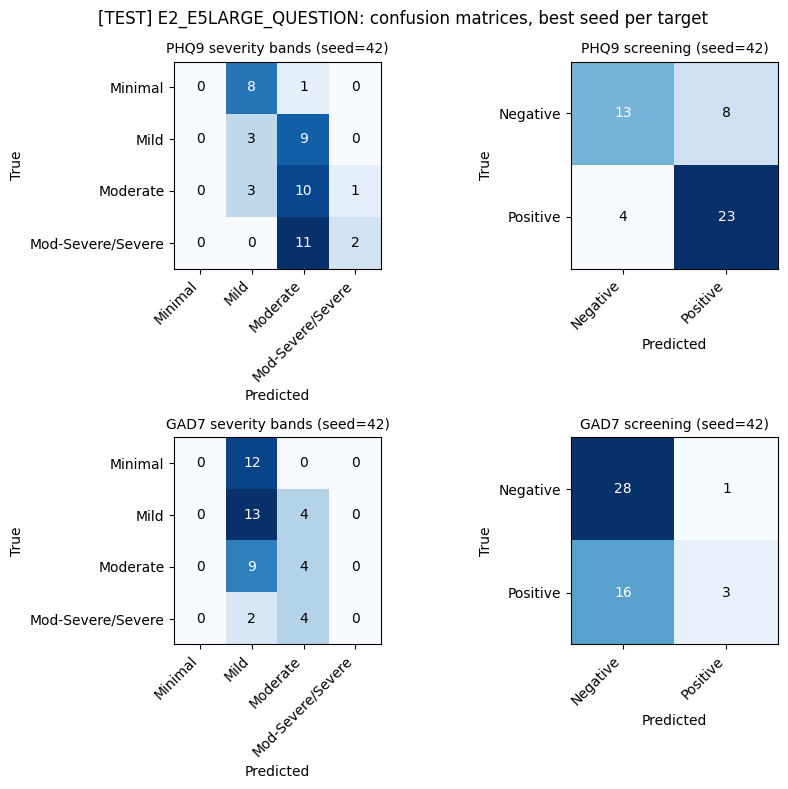

In [25]:
train_and_report(e5_arm(E5_MODELS[2], question_level=True))

### Stage 6: RoBERTa-es-mental (frozen)

`ELiRF/RoBERTa-es-mental-large`: `roberta-large-bne` continued with
masked-language-model pretraining on ~1.9M mental-health Reddit posts machine
translated into Spanish (ELiRF, UPV). It is a plain masked-language model, so
it is embedded exactly like BETO — mean pooling over the last hidden state,
no prefix, the same 512-token windows — and differs from `E1_BETO` in both the
backbone and the domain adaptation, since its own base checkpoint is no longer
published. The first run downloads ~1.4 GB.

E7_ROBERTA_MENTAL_QUESTION seed=42 target=PHQ9 best=SVR rmse=4.933 r2=0.194 (178.8s)
E7_ROBERTA_MENTAL_QUESTION seed=42 target=GAD7 best=LightGBM rmse=4.497 r2=0.201 (177.6s)
E7_ROBERTA_MENTAL_QUESTION done in 5.9 min
[TEST] E7_ROBERTA_MENTAL_QUESTION: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.497  4.933  3.695  4.053  0.201  0.194

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.580
DecisionTree,7.249
ExtraTrees,5.580
GradientBoosting,5.601
KNN,5.981
LightGBM,5.545
RandomForest,5.606
Ridge,6.902
SVR,5.410


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.677
DecisionTree,5.928
ExtraTrees,4.733
GradientBoosting,4.713
KNN,5.146
LightGBM,4.625
RandomForest,4.692
Ridge,6.263
SVR,4.669


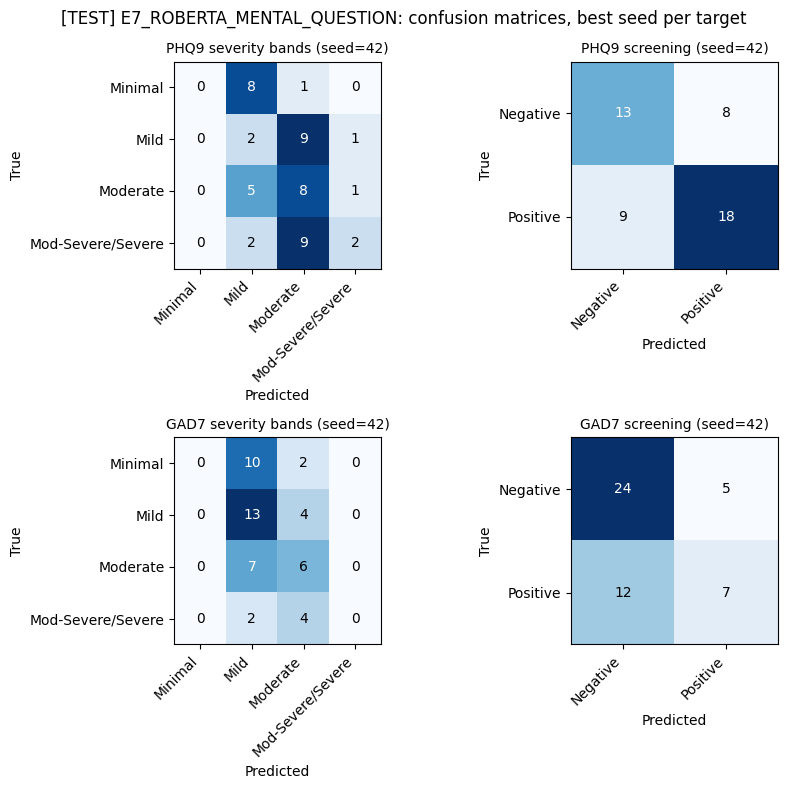

In [ ]:
train_and_report("E7_ROBERTA_MENTAL_QUESTION")

### Summary

Every arm scored on the same held-out participants, so rows compare directly.

In [27]:
log = logging_utils.load_all_runs()
log = log[log.augmentation == cfg.augmentation]
# `search` is part of the grouping: the same arm can appear both with and
# without hyperparameter search, and averaging across the two would pool
# results from different procedures into one meaningless number.
summary = log.groupby(["encoder", "search", "target"])[
    ["rmse", "mae", "r2"]].agg(["mean", "std"]).round(3)
present = set(summary.index.get_level_values("encoder"))
# Restricted to this notebook's own arms. The named-feature arms
# (E10-E15) are logged under their own family and were fitted with a
# narrower set of candidate regressors, so listing them here would
# rank runs produced by different selection procedures.
DENSE_ARMS = [e for e in ALL_ARMS if not e.startswith(("E10_", "E11_",
               "E12_", "E13_", "E14_", "E15_"))]
order = [e for e in DENSE_ARMS if e in present]

spread = (f"mean and SD across {len(cfg.seeds)} seeds" if len(cfg.seeds) > 1
          else f"single seed ({cfg.seeds[0]}), so the SD columns are empty")
print(f"[TEST] {spread}, on the {N_TEST} held-out participants.")
print("RMSE and MAE in PHQ-9 / GAD-7 points (lower is better); R2 is the fraction of")
print("variance explained (0 = no better than predicting the training mean, negative = worse).")
display(summary.loc[order])

[TEST] single seed (42), so the SD columns are empty, on the 48 held-out participants.
RMSE and MAE in PHQ-9 / GAD-7 points (lower is better); R2 is the fraction of
variance explained (0 = no better than predicting the training mean, negative = worse).


rmse        mae         r2    
                                             mean std   mean std   mean std
encoder                    search   target                                 
E0_TFIDF                   defaults GAD7    4.916 NaN  4.047 NaN  0.045 NaN
                                    PHQ9    5.452 NaN  4.412 NaN  0.015 NaN
E1_BETO                    defaults GAD7    4.456 NaN  3.646 NaN  0.216 NaN
                                    PHQ9    4.913 NaN  3.968 NaN  0.201 NaN
E2_E5SMALL                 defaults GAD7    4.563 NaN  3.756 NaN  0.178 NaN
                                    PHQ9    4.830 NaN  3.912 NaN  0.227 NaN
E2_E5BASE                  defaults GAD7    4.289 NaN  3.367 NaN  0.273 NaN
                                    PHQ9    4.871 NaN  4.045 NaN  0.214 NaN
E2_E5LARGE                 defaults GAD7    4.187 NaN  3.275 NaN  0.307 NaN
                                    PHQ9    4.703 NaN  3.791 NaN  0.267 NaN
E7_ROBERTA_MENTAL          defaults GAD7    4.362 NaN  3.413 NaN  0.248 NaN
                                    PHQ9    4.987 NaN  4.070 NaN  0.176 NaN
E0_TFIDF_QUESTION          defaults GAD7    4.828 NaN  3.978 NaN  0.079 NaN
                                    PHQ9    5.292 NaN  4.301 NaN  0.073 NaN
E1_BETO_QUESTION           defaults GAD7    4.559 NaN  3.720 NaN  0.179 NaN
                                    PHQ9    5.005 NaN  4.111 NaN  0.170 NaN
E2_E5SMALL_QUESTION        defaults GAD7    4.490 NaN  3.675 NaN  0.204 NaN
                                    PHQ9    4.916 NaN  4.044 NaN  0.200 NaN
E2_E5BASE_QUESTION         defaults GAD7    4.376 NaN  3.522 NaN  0.243 NaN
                                    PHQ9    4.788 NaN  3.956 NaN  0.241 NaN
E2_E5LARGE_QUESTION        defaults GAD7    4.541 NaN  3.686 NaN  0.186 NaN
                                    PHQ9    4.634 NaN  3.826 NaN  0.289 NaN
E7_ROBERTA_MENTAL_QUESTION defaults GAD7    4.497 NaN  3.695 NaN  0.201 NaN
                                    PHQ9    4.933 NaN  4.053 NaN  0.194 NaN

### Which question carries the signal

Each question asks about something different while sharing the participant's
label, so scoring each separately says whether one does most of the work.
Read on the test set: descriptive, not a basis for selection.

In [28]:
from sklearn.metrics import mean_squared_error
from src.regression_models import search_best_model, best_of

def per_question_error(encoder_name, target=config.PRIMARY_TARGET, seed=cfg.seeds[0]):
    """Refits the selected pipeline for one seed and scores each question separately."""
    X_all, preprocessor = encoder_data(encoder_name, combined, docs_all, embeddings, cfg)
    X_train_enc, X_test_enc = X_all.loc[q_train.index], X_all.loc[q_test.index]
    col = config.TARGET_COLUMNS[target]

    strat = splits.stratify_key(q_train)
    cv = splits.cv_splitter(groups=groups, n_splits=cfg.n_cv_splits, random_state=seed)
    folds = list(cv.split(X_train_enc, strat, groups=groups))
    results = search_best_model(X_train_enc, q_train[col].to_numpy(), preprocessor, folds,
                                 seed=seed, n_iter=cfg.n_search_iter)
    _, estimator = best_of(results)

    frame = q_test.assign(pred=estimator.predict(X_test_enc))
    rows = [{"question": q, "n_test_rows": len(c),
             "rmse": mean_squared_error(c[col], c["pred"]) ** 0.5}
            for q, c in frame.groupby("question")]
    return pd.DataFrame(rows).set_index("question").round(3)

print(f"[TEST] per-question RMSE, {config.PRIMARY_TARGET}")
display(per_question_error(e5_arm(E5_MODELS[0], question_level=True)))

[TEST] per-question RMSE, PHQ9


,n_test_rows,rmse
question,,
Q01,48,5.080
Q02,48,5.246
Q03,48,5.008
Q04,24,6.041
